In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

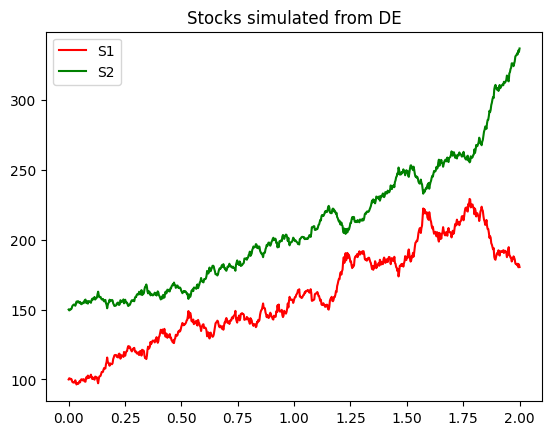

In [107]:
def simulate_stocks(mu1,mu2,sigma1,sigma2,rho,N,T,S10,S20):
    t=np.linspace(0,T,N)
    S1=np.zeros_like(t)
    S2=np.zeros_like(t)
    S2[0]=S20
    S1[0]=S10
    s1=S10
    s2=S20
    for x in range(1,N):
        dw1=np.sqrt(T/N)*np.random.randn()
        dw2=np.sqrt(T/N)*np.random.randn()
        s1+=mu1*s1*(T/N)+((sigma1*s1*s1)/(np.sqrt(s1*s1+s2*s2)))*dw1+rho*s1*s2*dw2/np.sqrt(s1*s1+s2*s2)
        s2+=mu2*s2*(T/N)+((sigma2*s2*s2)/(np.sqrt(s1*s1+s2*s2)))*dw2+rho*s1*s2*dw1/np.sqrt(s1*s1+s2*s2)
        S1[x]=s1
        S2[x]=s2
    return t,S1,S2

t,Stock1,Stock2=simulate_stocks(0.5,0.3,0.3,0.1,-0.2,750,2,100,150)
plt.plot(t,Stock1,color="red",label="S1")
plt.plot(t,Stock2,color="green",label="S2")
plt.title("Stocks simulated from DE")
plt.legend()
plt.show()